In [ ]:
!pip install torch torchvision lpips kornia matplotlib tqdm

In [10]:
# Cell 2: Imports and utility functions
import torch
import torch.profiler
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import lpips
import kornia
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

to_tensor = T.Compose([
    T.ToTensor(),  # Converts to [0,1]
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1,1] for LPIPS
])

to_pil = T.Compose([
    T.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]),
    T.ToPILImage()
])

In [16]:
target_path = 'test-images/mac.png'     
can_path = 'Logos/chiquita-logo.png'  

# === Configuration: Set your real-world sizes ===
canvas_width_in = 8.5     # canvas width in inches
canvas_height_in = 10.0    # canvas height in inches
can_width_in = 1.0        # can width in inches
can_height_in = 1.0       # can height in inches
dpi = 30                   # dots per inch (resolution)
downscale_factor = 1.0    # apply 25% scaling for optimization

# === Convert inches to pixels ===
canvas_width_px = int(canvas_width_in * dpi)
canvas_height_px = int(canvas_height_in * dpi)
can_width_px = int(can_width_in * dpi)
can_height_px = int(can_height_in * dpi)

print(f"Canvas: {canvas_width_px} x {canvas_height_px} px")
print(f"Each can: {can_width_px} x {can_height_px} px")

# === Load and resize target/can image ===
target_pil = Image.open(target_path).convert('RGB').resize((canvas_width_px, canvas_height_px))
can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))

# === Convert to full-resolution tensors ===
target_tensor_full = to_tensor(target_pil).unsqueeze(0).to(device)
can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)

# === Downscale all tensors for optimization ===
def downscale(tensor, factor):
    return F.interpolate(tensor, scale_factor=factor, mode='bilinear', align_corners=False)

target_tensor = downscale(target_tensor_full, downscale_factor)
can_rgb = downscale(can_rgb_full, downscale_factor)
can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)

# === Create blank canvas at downscaled resolution ===
canvas = torch.zeros_like(target_tensor).detach()


Canvas: 255 x 300 px
Each can: 30 x 30 px


In [21]:
# Cell 4: Multi-Can Placement and Optimization

import os
import glob
import torch
import torchvision.transforms as T
from PIL import Image
import lpips
import kornia.geometry.transform as KGT
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# === Load can images from the specified folder ===
def load_can_images(can_folder):
    can_paths = glob.glob(os.path.join(can_folder, '*.png')) + glob.glob(os.path.join(can_folder, '*.jpg')) + glob.glob(os.path.join(can_folder, '*.jpeg'))
    can_images = []
    for can_path in can_paths:
        try:
            can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))
            can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
            can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)

            can_rgb = downscale(can_rgb_full, downscale_factor)
            can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)
            can_images.append((can_rgb, can_alpha))
        except Exception as e:
            print(f"Error loading image {can_path}: {e}")
    return can_images

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Define the number of cans to place ===
num_cans = 5  # Adjust as needed

# === Define the folder containing can images ===
can_folder = 'Logos/'  # Replace with the actual path to your can images folder
can_images = load_can_images(can_folder)
if not can_images:
    raise ValueError("No can images found in the specified folder.")

# === Load LPIPS metric ===
lpips_loss = lpips.LPIPS(net='vgg').to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\weights\v0.1\vgg.pth


In [ ]:
# === Define the transformation functions (same as before) ===
import itertools
from matplotlib import animation


def create_transformation_matrix(x_offset, y_offset, rotation_angle, canvas_width, canvas_height):
    """Creates a transformation matrix for translation and rotation."""
    # Normalize offsets to range [-1, 1]
    x_offset_norm = (x_offset / canvas_width) * 2 - 1
    y_offset_norm = (y_offset / canvas_height) * 2 - 1

    # Create translation matrix
    translation_matrix = torch.eye(3)
    translation_matrix[0, 2] = x_offset_norm
    translation_matrix[1, 2] = y_offset_norm

    # Create rotation matrix
    rotation_matrix = torch.eye(3)
    rotation_angle_rad = torch.deg2rad(torch.tensor(rotation_angle))
    rotation_matrix[0, 0] = torch.cos(rotation_angle_rad)
    rotation_matrix[0, 1] = -torch.sin(rotation_angle_rad)
    rotation_matrix[1, 0] = torch.sin(rotation_angle_rad)
    rotation_matrix[1, 1] = torch.cos(rotation_angle_rad)

    # Combine rotation and translation (rotation first)
    transformation_matrix = translation_matrix @ rotation_matrix

    return transformation_matrix[0:2].unsqueeze(0).to(device)  # Return 2x3 matrix


def place_can(canvas, can_rgb, can_alpha, x_offset, y_offset, rotation_angle):
    """Places the can on the canvas with specified offset and rotation."""
    canvas_height, canvas_width = canvas.shape[2], canvas.shape[3]

    # Create transformation matrix
    transformation_matrix = create_transformation_matrix(x_offset, y_offset, rotation_angle, canvas_width, canvas_height)

    # Apply the transformation to the can
    transformed_can_rgb = KGT.warp_affine(can_rgb, transformation_matrix, dsize=(canvas_height, canvas_width))
    transformed_can_alpha = KGT.warp_affine(can_alpha, transformation_matrix, dsize=(canvas_height, canvas_width))

    # Handle out-of-bounds scenarios by clamping the alpha mask
    transformed_can_alpha = transformed_can_alpha.clamp(0, 1)

    # Composite the can onto the canvas using the alpha mask
    for c in range(3):  # Iterate over RGB channels
        canvas[:, c, :, :] = (
            (1 - transformed_can_alpha) * canvas[:, c, :, :] +
            transformed_can_alpha * transformed_can_rgb[:, c, :, :]
        )

    return canvas

# === Multi-Can Optimization ===


import os
import matplotlib.pyplot as plt

def optimize_multi_can_placement(target_tensor, canvas, can_images, num_cans,
                                x_range, y_range, rotation_range,
                                num_iterations=64,  # Iterations per level
                                num_levels=3,  # Number of coarse-to-fine levels
                                grid_search_levels=1,  # Number of levels to use grid search
                                grid_steps=5,  # Number of grid steps per dimension
                                debug=False):  # Debug flag
    """
    Optimizes multi-can placement using coarse-to-fine search with grid search at coarser levels
    and random search at finer levels.

    Args:
        # ... (previous arguments remain the same)
        debug: If True, save debug images.
    """
    canvas_height, canvas_width = canvas.shape[2], canvas.shape[3]
    can_placements = []
    current_canvas = canvas.clone()

    # Create a directory for debug images if debug is True
    if debug:
        debug_dir = 'debug_images'
        os.makedirs(debug_dir, exist_ok=True)

    frame_count = 0

    # Sample random can image
    can_index = random.randint(0, len(can_images) - 1)
    can_rgb, can_alpha = can_images[can_index]
    
    for can_idx in range(num_cans):
        best_lpips_score = float('inf')
        best_x, best_y, best_rotation = 0, 0, 0
        best_can_index = 0

        # Initialize search ranges for the current can
        current_x_range = x_range
        current_y_range = y_range
        current_rotation_range = rotation_range

        print(f"\nInitial ranges for Can {can_idx + 1}:")
        print(f"X range: {current_x_range}")
        print(f"Y range: {current_y_range}")
        print(f"Rotation range: {current_rotation_range}")

        for level in range(num_levels):
            print(f"\nCan {can_idx + 1}/{num_cans}, Level {level + 1}/{num_levels}")
            print(f"Current X range: {current_x_range}")
            print(f"Current Y range: {current_y_range}")
            print(f"Current Rotation range: {current_rotation_range}")

            if level < grid_search_levels:
                # Grid Search
                print(f"Using Grid Search (Level {level + 1})")
                x_steps = torch.linspace(current_x_range[0], current_x_range[1], grid_steps)
                y_steps = torch.linspace(current_y_range[0], current_y_range[1], grid_steps)
                rotation_steps = torch.linspace(current_rotation_range[0], current_rotation_range[1], grid_steps)

                total_combinations = len(x_steps) * len(y_steps) * len(rotation_steps)
                with tqdm(total=total_combinations, desc=f"Grid Search Can {can_idx + 1}/{num_cans}, Level {level + 1}/{num_levels}") as pbar:
                    for step, (x, y, rotation) in enumerate(itertools.product(x_steps, y_steps, rotation_steps)):
                        

                        # Create a copy of the canvas for each placement attempt
                        temp_canvas = current_canvas.clone()

                        # Place the can on the canvas
                        temp_canvas = place_can(temp_canvas, can_rgb, can_alpha, x, y, rotation)

                        # Calculate LPIPS score
                        lpips_score = lpips_loss(temp_canvas, target_tensor).item()

                        # Update best score and placement if needed
                        if lpips_score < best_lpips_score:
                            best_lpips_score = lpips_score
                            best_x, best_y, best_rotation = x, y, rotation
                            best_can_index = can_index

                        # Update the progress bar with the current best score
                        pbar.set_postfix({'LPIPS': best_lpips_score})
                        pbar.update(1)

                        if debug and step % 10 == 0:  # Save every 10th frame to reduce the number of images
                            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
                            ax1.imshow(temp_canvas[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax1.set_title(f"Current Placement")
                            ax1.axis('off')
                            ax2.imshow(can_rgb[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax2.set_title(f"Current Can Image")
                            ax2.axis('off')
                            plt.suptitle(f"Can {can_idx + 1}, Level {level + 1} (Grid Search), Step {step + 1}/{total_combinations}")
                            plt.savefig(os.path.join(debug_dir, f'frame_{frame_count:04d}.png'))
                            plt.close(fig)
                            frame_count += 1

            else:
                # Random Search
                print(f"Using Random Search (Level {level + 1})")
                with tqdm(total=num_iterations, desc=f"Random Search Can {can_idx + 1}/{num_cans}, Level {level + 1}/{num_levels}") as pbar:
                    for i in range(num_iterations):
                        # Sample random can image
                        can_index = random.randint(0, len(can_images) - 1)
                        can_rgb, can_alpha = can_images[can_index]

                        # Sample random placement parameters within the current ranges
                        x = torch.rand(1).item() * (current_x_range[1] - current_x_range[0]) + current_x_range[0]
                        y = torch.rand(1).item() * (current_y_range[1] - current_y_range[0]) + current_y_range[0]
                        rotation = torch.rand(1).item() * (current_rotation_range[1] - current_rotation_range[0]) + current_rotation_range[0]

                        # Create a copy of the canvas for each placement attempt
                        temp_canvas = current_canvas.clone()

                        # Place the can on the canvas
                        temp_canvas = place_can(temp_canvas, can_rgb, can_alpha, x, y, rotation)

                        # Calculate LPIPS score
                        lpips_score = lpips_loss(temp_canvas, target_tensor).item()

                        # Update best score and placement if needed
                        if lpips_score < best_lpips_score:
                            best_lpips_score = lpips_score
                            best_x, best_y, best_rotation = x, y, rotation
                            best_can_index = can_index

                        # Update the progress bar with the current best score
                        pbar.set_postfix({'LPIPS': best_lpips_score})
                        pbar.update(1)

                        if debug and i % 5 == 0:  # Save every 5th frame to reduce the number of images
                            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
                            ax1.imshow(temp_canvas[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax1.set_title(f"Current Placement")
                            ax1.axis('off')
                            ax2.imshow(can_rgb[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax2.set_title(f"Current Can Image")
                            ax2.axis('off')
                            plt.suptitle(f"Can {can_idx + 1}, Level {level + 1} (Random Search), Iteration {i + 1}/{num_iterations}")
                            plt.savefig(os.path.join(debug_dir, f'frame_{frame_count:04d}.png'))
                            plt.close(fig)
                            frame_count += 1

            print(f"Can {can_idx + 1}, Level {level + 1}: Best LPIPS score: {best_lpips_score}")
            print(f"Can {can_idx + 1}, Level {level + 1}: Best x: {best_x}, Best y: {best_y}, Best rotation: {best_rotation}")

            # Refine the search ranges for the next level
            x_range_width = current_x_range[1] - current_x_range[0]
            y_range_width = current_y_range[1] - current_y_range[0]
            rotation_range_width = current_rotation_range[1] - current_rotation_range[0]

            # Reduce the search range by half around the best values
            current_x_range = (max(x_range[0], best_x - x_range_width / 4), min(x_range[1], best_x + x_range_width / 4))
            current_y_range = (max(y_range[0], best_y - y_range_width / 4), min(y_range[1], best_y + y_range_width / 4))
            current_rotation_range = (max(rotation_range[0], best_rotation - rotation_range_width / 4), min(rotation_range[1], best_rotation + rotation_range_width / 4))

            print(f"\nUpdated ranges for next level:")
            print(f"New X range: {current_x_range}")
            print(f"New Y range: {current_y_range}")
            print(f"New Rotation range: {current_rotation_range}")
            
        # After all levels, place the best can on the current canvas
        best_can_rgb, best_can_alpha = can_images[best_can_index]
        current_canvas = place_can(current_canvas, best_can_rgb, best_can_alpha, best_x, best_y, best_rotation)

        # Store the can placement
        can_placements.append((best_x, best_y, best_rotation, best_can_index))

    return current_canvas, can_placements


Initial ranges for Can 1:
X range: (0, 255.0)
Y range: (0, 300.0)
Rotation range: (-180, 180)

Can 1/1, Level 1/3
Current X range: (0, 255.0)
Current Y range: (0, 300.0)
Current Rotation range: (-180, 180)
Using Grid Search (Level 1)


Grid Search Can 1/1, Level 1/3:   0%|          | 0/27 [00:00<?, ?it/s]C:\Users\Eoin\AppData\Local\Temp\ipykernel_27520\3565170420.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation_angle_rad = torch.deg2rad(torch.tensor(rotation_angle))
Grid Search Can 1/1, Level 1/3: 100%|██████████| 27/27 [00:12<00:00,  2.13it/s, LPIPS=0.931]


Can 1, Level 1: Best LPIPS score: 0.931194543838501
Can 1, Level 1: Best x: 255.0, Best y: 300.0, Best rotation: 0.0

Updated ranges for next level:
New X range: (tensor(191.2500), 255.0)
New Y range: (tensor(225.), 300.0)
New Rotation range: (tensor(-90.), tensor(90.))

Can 1/1, Level 2/3
Current X range: (tensor(191.2500), 255.0)
Current Y range: (tensor(225.), 300.0)
Current Rotation range: (tensor(-90.), tensor(90.))
Using Grid Search (Level 2)


Grid Search Can 1/1, Level 2/3: 100%|██████████| 27/27 [00:12<00:00,  2.08it/s, LPIPS=0.931]


Can 1, Level 2: Best LPIPS score: 0.931194543838501
Can 1, Level 2: Best x: 255.0, Best y: 300.0, Best rotation: 0.0

Updated ranges for next level:
New X range: (tensor(239.0625), 255.0)
New Y range: (tensor(281.2500), 300.0)
New Rotation range: (tensor(-45.), tensor(45.))

Can 1/1, Level 3/3
Current X range: (tensor(239.0625), 255.0)
Current Y range: (tensor(281.2500), 300.0)
Current Rotation range: (tensor(-45.), tensor(45.))
Using Random Search (Level 3)


Random Search Can 1/1, Level 3/3: 100%|██████████| 16/16 [00:08<00:00,  1.84it/s, LPIPS=0.929]


Can 1, Level 3: Best LPIPS score: 0.9285420179367065
Can 1, Level 3: Best x: 246.90895080566406, Best y: 299.2397155761719, Best rotation: -20.405832290649414

Updated ranges for next level:
New X range: (tensor(242.9246), tensor(250.8933))
New Y range: (tensor(294.5522), 300.0)
New Rotation range: (tensor(-42.9058), tensor(2.0942))


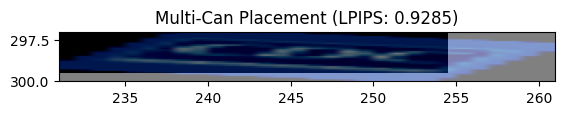


Can Placements:
Can 1: x=246.91, y=299.24, rotation=-20.41, image_index=170


In [42]:
num_cans = 1  # Adjust as needed

# === Define the folder containing can images ===
can_folder = 'Logos/'  # Replace with the actual path to your can images folder
can_images = load_can_images(can_folder)
if not can_images:
    raise ValueError("No can images found in the specified folder.")

# === Define search ranges ===
x_range = (0, canvas_width_px * downscale_factor)  # X offset range
y_range = (0, canvas_height_px * downscale_factor) # Y offset range
rotation_range = (-180, 180)                       # Rotation range in degrees

# === Run the multi-can optimization ===
final_canvas, can_placements = optimize_multi_can_placement(
    target_tensor, canvas, can_images, num_cans,
    x_range, y_range, rotation_range,
    num_iterations=16, num_levels=3,  # Adjust as needed
    grid_search_levels=2, grid_steps=3, debug=True
)

# === Display the result ===
plt.imshow(final_canvas[0].cpu().permute(1, 2, 0).clamp(0, 1))
plt.title(f"Multi-Can Placement (LPIPS: {lpips_loss(final_canvas, target_tensor).item():.4f})")

# === Manually plot the cans on the canvas ===
for i, (x, y, rotation, can_index) in enumerate(can_placements):
    can_rgb, _ = can_images[can_index]
    can_height, can_width = can_rgb.shape[1], can_rgb.shape[2]

    # Calculate the can's position on the canvas
    can_x = int(x - can_width / 2)
    can_y = int(y - can_height / 2)

    # Rotate the can image
    can_rgb_rotated = KGT.rotate(can_rgb, torch.tensor([rotation]))

    # Plot the can on the canvas
    plt.imshow(can_rgb_rotated[0].cpu().permute(1, 2, 0).clamp(0, 1), extent=(can_x, can_x + can_width, can_y + can_height, can_y), alpha=0.5)

plt.show()

# === Print can placements ===
print("\nCan Placements:")
for i, (x, y, rotation, can_index) in enumerate(can_placements):
    print(f"Can {i + 1}: x={x:.2f}, y={y:.2f}, rotation={rotation:.2f}, image_index={can_index}")